In [1]:
"""
Automatically reloads libraries and utilities every time a cell is run
"""
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from utils.PSF_helpers import *
from utils.Plot_helpers import *
from utils.Zernike_helpers import *
from utils.Booth_helpers import *

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [3]:
#minor style things to make the figures look nice
plt.style.use("bmh")
plt.rcParams["figure.figsize"] = [548 / 72, 390 / 72]
plt.rcParams["font.size"] = 12
plt.rcParams['text.usetex'] = True
plt.rcParams["figure.dpi"] = 300
import os
os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

In [4]:
N_order = 3                # 3 for 3P, 2 for 2P
lambd = 1.3e-3             # Wavelength [mm]
n = 1.333                  # Refractive index
k = 2*n*np.pi/lambd        # Wavenumber
num_apt = 1.05             # Numerical aperture
f = 7.2                    # Focal length of objective (Olympus) [mm]
theta_grid_size = 64            # BFP resolution
L_bfp = 15.12              # BFP diameter [mm]
mag = 4                    # Magnification rate from input to objective
w_0 = 3.5                  # mm
num_apt = 1.05

In [313]:
r_pupil = f * num_apt
r_bfp = L_bfp / 2
na_eff = num_apt
#effective NA can be limited by the size of the back focal plane
if r_bfp < r_pupil:
    na_eff = r_bfp / f
alpha = np.arcsin(na_eff / n)

R_BFP = r_bfp

microscope = Microscope(N_order, lambd, n, num_apt, f, mag, w_0, L_bfp, theta_grid_size)
L_ffp = 0.002
grid_ffp = 128
grid = Centered_Square_Grid(L_ffp, grid_ffp, 0)
size = 0.00015
bead_img = Bead_Image(grid,  [size,
                                        -size,
                                        -size], [0,
                             -size,
                             size], [0.0002,
                                                   0.0002,
                                                   0.0002])

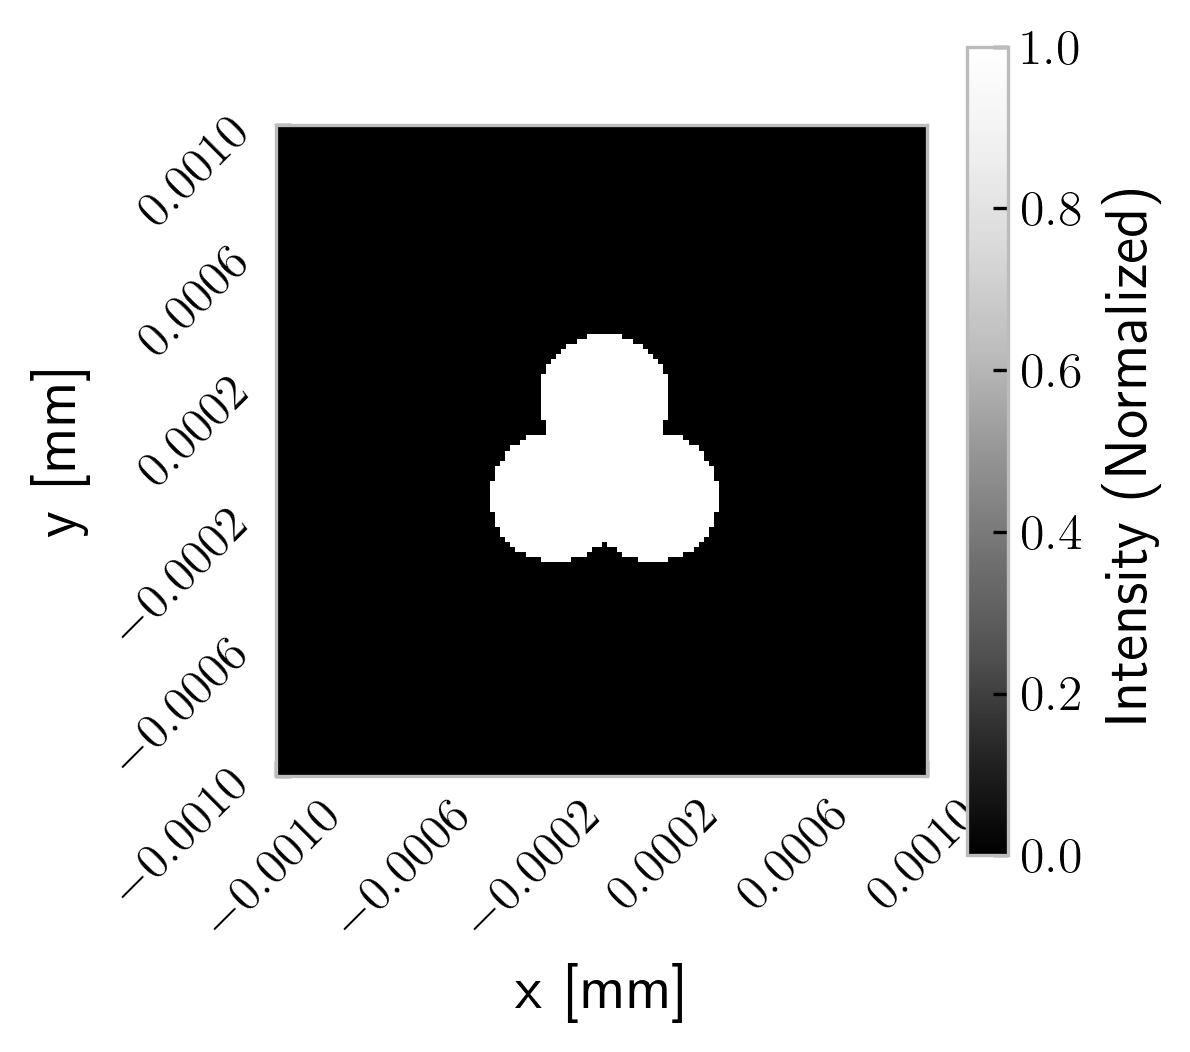

In [314]:
plot_intensity(*bead_img.get_xy(), bead_img.image_mask)
X = bead_img.image_mask

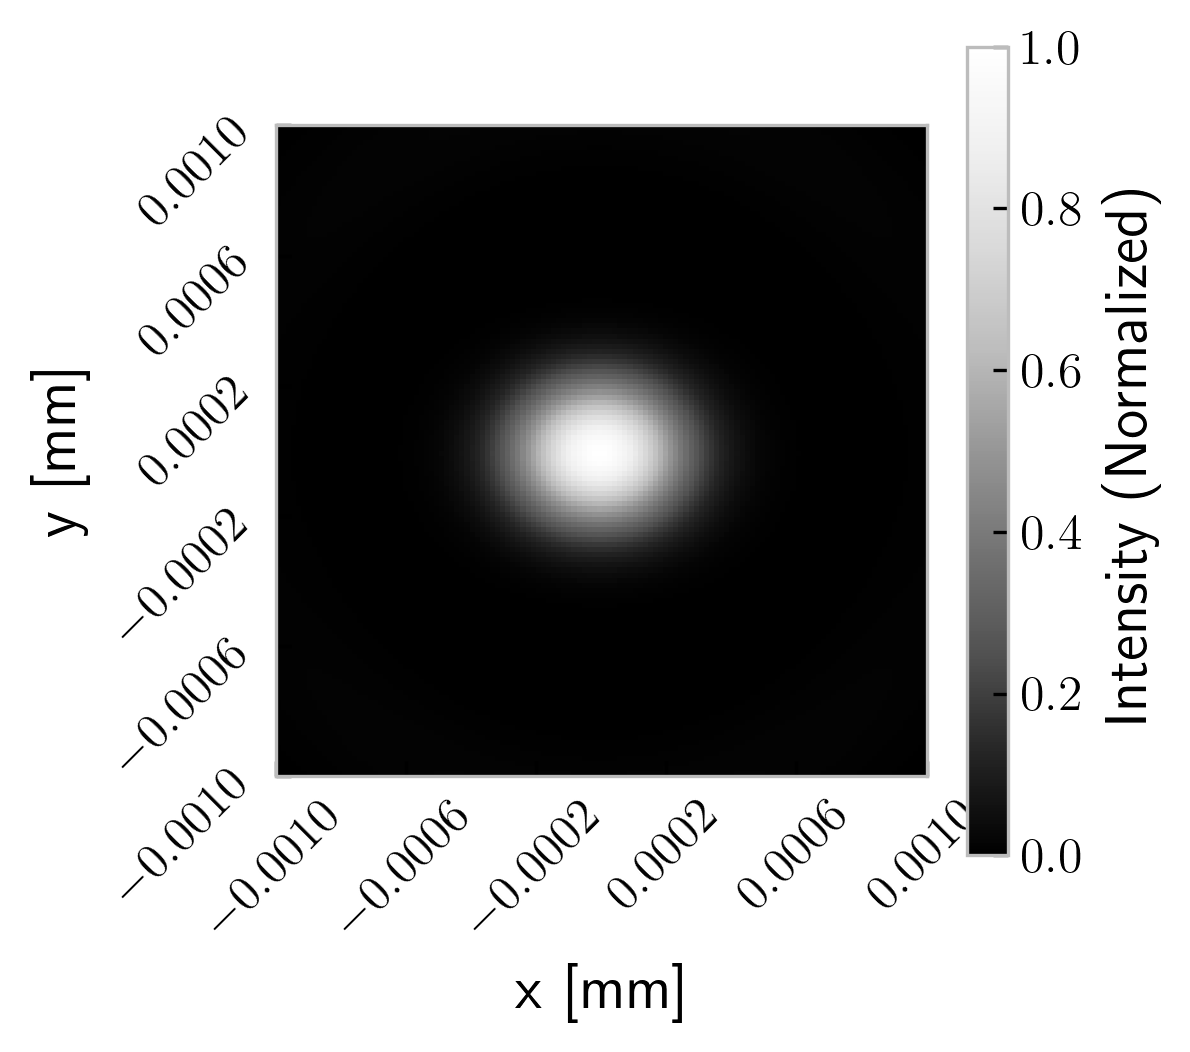

In [319]:
true_modes = [[0, 4], [-3, 3]]
true_c = [0.4, 0.0]
aberration = Aberration(true_modes, true_c)
x, y, PSF = microscope.compute_PSF(grid, aberration)
plot_intensity(x, y, PSF)

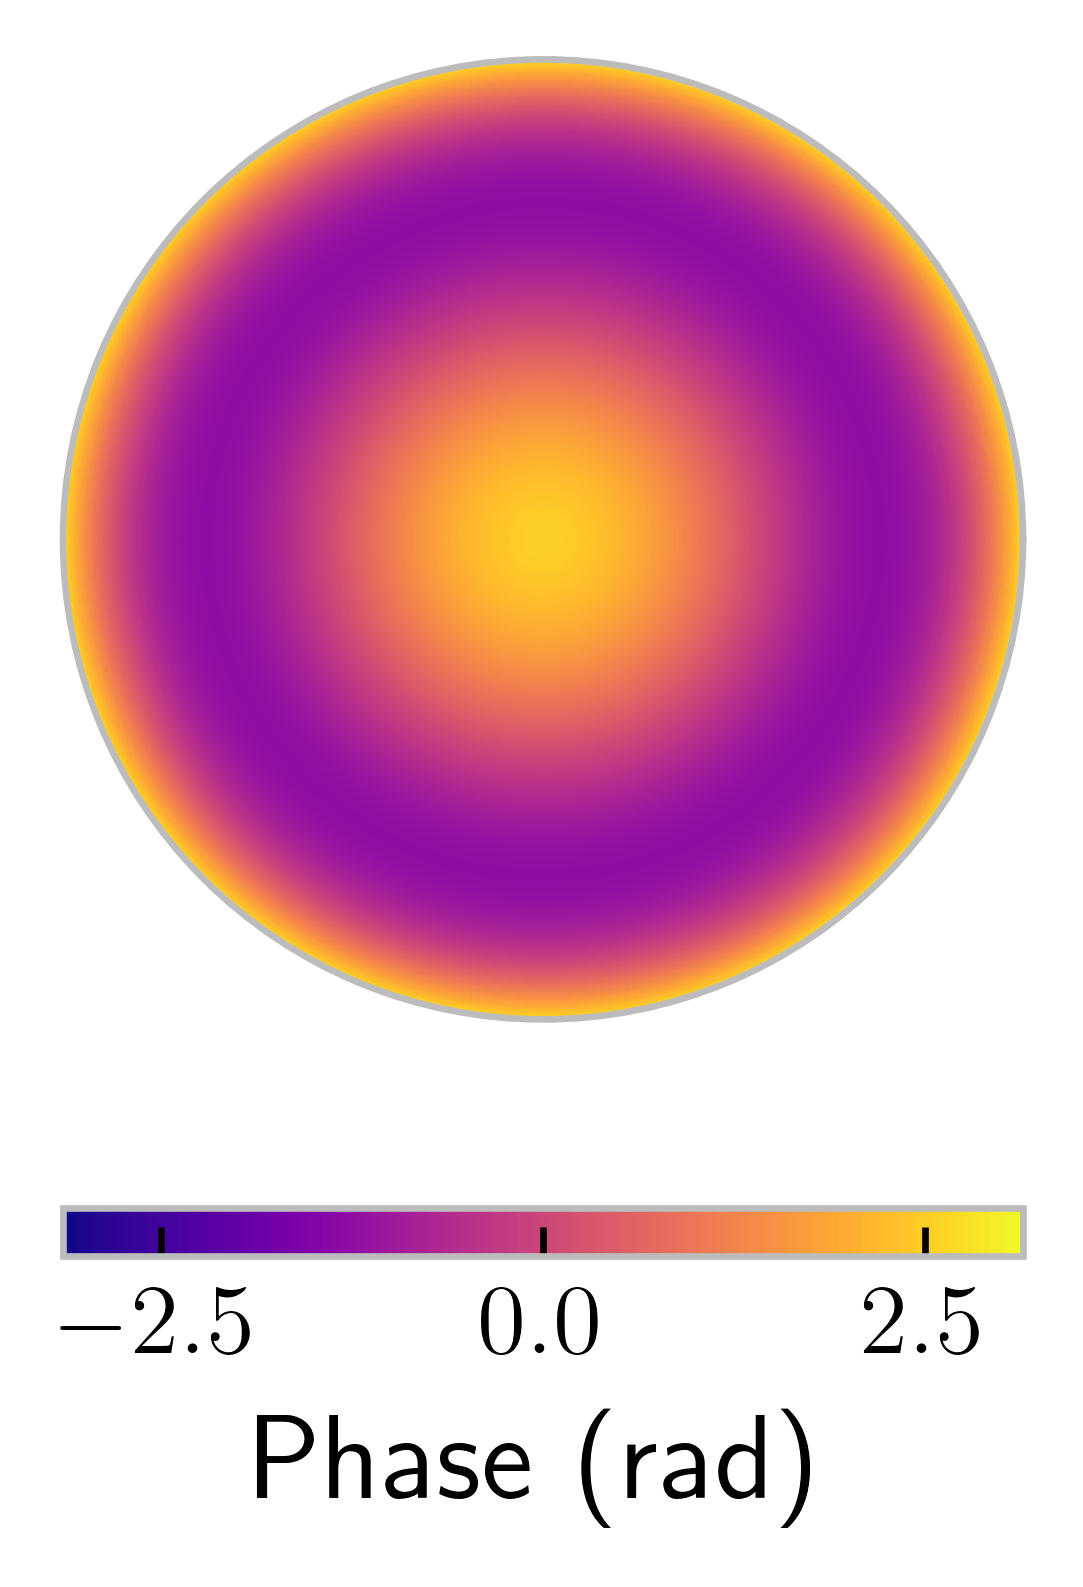

In [320]:
zernike_plot(aberration.construct_map(alpha), alpha)

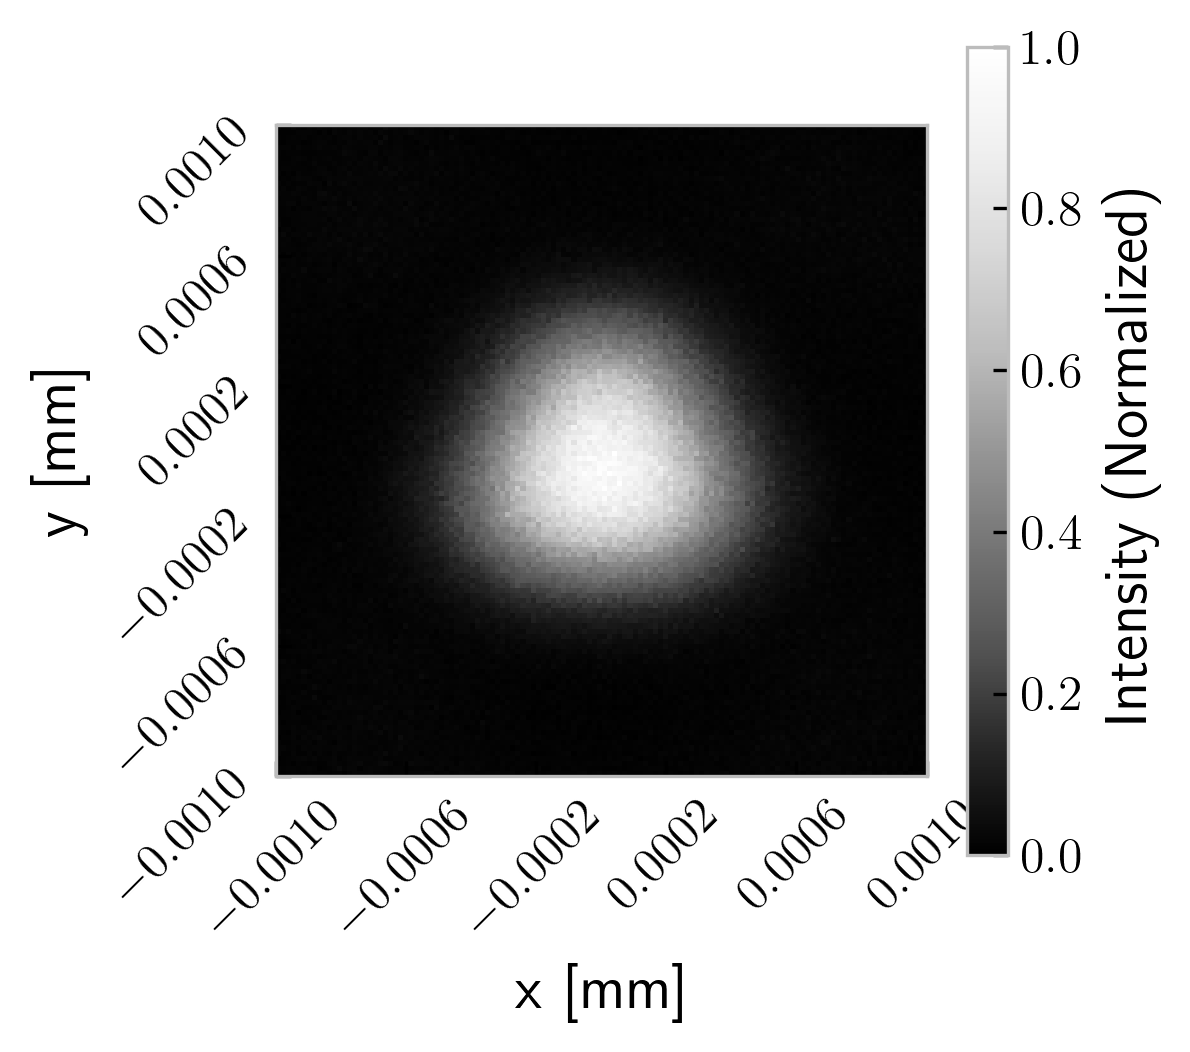

In [321]:
exposure = 1000
background = 5
rng = np.random.default_rng(15)
Y = rng.poisson(psf_convolve(X, PSF) * exposure + background)
plot_intensity(x, y, Y)

In [265]:
#Y/Y_hat is the convolved image
#a_hat is the estimated aberrations
#X is the known image mask

def compute_prediction(X, a_modes, a, background, exposure):
    _, _, PSF = microscope.compute_PSF(grid, Aberration(a_modes.tolist(), a.tolist()))
    Y_hat = psf_convolve(X, PSF) * exposure + background
    #ensure positive values
    Y_hat = np.clip(Y_hat, 0, np.inf)
    return Y_hat

def log_a_prior(a):
    #a_hat must be between 0 and 1
    if np.any(a < 0) or np.any(a > 1):
        return -np.inf
    return 0

#poisson likelihood
def cash(Y, Y_hat):
    #ensure positive values
    Y_hat = np.clip(Y_hat, 1e-25, np.inf)
    stat = 2 * (Y_hat - Y * np.log(Y_hat))
    return stat

def log_likelihood(X, Y, a_modes, a, background, exposure):
    Y_hat = compute_prediction(X, a_modes, a, background, exposure)
    return cash(Y, Y_hat).sum()

def log_posterior(X, Y, a_modes, a, background, exposure):
    return log_a_prior(a) + log_likelihood(
        X = X, Y = Y, a_modes = a_modes, a = a, background=background, exposure=exposure
    )

def random_coin(p):
    unif = np.random.uniform(0, 1)
    return unif <= p

In [223]:
def deconvolve_mcmc_a(X_init, Y, a_modes, a_init, background, exposure, n_samples):
    a_trace = np.zeros((n_samples, len(a_modes)))
    log_post_trace = np.zeros(n_samples)
    rng = np.random.default_rng(15)
    for i in tqdm(range(n_samples)):
        #add gaussian noise to the aberration coefficients
        a_hat = a_init + rng.normal(0, 0.0001, len(a_init))
        prob = log_posterior(X=X_init, 
                             Y = Y,
                             a_modes = a_modes,
                             a = a_hat,
                             background = background,
                             exposure = exposure)
        prob_init = log_posterior(X=X_init, 
                             Y = Y,
                             a_modes = a_modes,
                             a = a_init,
                             background = background,
                             exposure = exposure)

        acceptance = min(np.exp(prob_init - prob), 1)

        if random_coin(acceptance) and np.isfinite(prob):
            a_init = a_hat

        a_trace[i] = a_init
        log_post_trace[i] = prob

    return {
        "a-trace": a_trace,
        "log-posterior-trace": log_post_trace,
    }

In [224]:
#Y/Y_hat is the convolved image
#a_hat is the estimated aberrations
#X is the known image mask

def compute_prediction_with_PSF(X, PSF, background, exposure):
    Y_hat = psf_convolve(X, PSF) * exposure + background
    #ensure positive values
    Y_hat = np.clip(Y_hat, 0, np.inf)
    return Y_hat

def log_X_prior(X, eps = 1e-5):
    
    dx = np.zeros_like(X)
    dy = np.zeros_like(X)

    dx[:-1, :] = X[1:, :] - X[:-1, :]   # vertical gradient
    dy[:, :-1] = X[:, 1:] - X[:, :-1]   # horizontal gradient

    grad_norm_sq = dx**2 + dy**2

    return np.sum(np.sqrt(grad_norm_sq + eps**2))

#poisson likelihood
def cash(Y, Y_hat):
    #ensure positive values
    Y_hat = np.clip(Y_hat, 1e-25, np.inf)
    stat = 2 * (Y_hat - Y * np.log(Y_hat))
    return stat

def log_likelihood_with_PSF(X, Y, PSF, background, exposure):
    Y_hat = compute_prediction_with_PSF(X, PSF, background, exposure)
    return cash(Y, Y_hat).sum()

def log_posterior_with_PSF(X, Y, PSF, background, exposure):
    return 1 * log_X_prior(X) + log_likelihood_with_PSF(
        X = X, Y = Y, PSF = PSF, background=background, exposure=exposure
    )

def random_coin(p):
    unif = np.random.uniform(0, 1)
    return unif <= p

In [225]:
def deconvolve_mcmc_X(X_init, Y, a_modes, a_init, background, exposure, n_samples):
    X_trace = np.zeros((n_samples, len(X_init), len(X_init)))
    log_post_trace = np.zeros(n_samples)
    rng = np.random.default_rng(15)

    _, _, PSF = microscope.compute_PSF(grid, Aberration(a_modes.tolist(), a_init.tolist()))
    for i in tqdm(range(n_samples)):
        #swap a random pixel in X 
        X_hat = np.copy(X_init) 
        for k in range(1):
             a = int(np.floor(rng.uniform(0, len(X_hat))))
             b = int(np.floor(rng.uniform(0, len(X_hat))))
             X_hat[a, b] = 1 - X_hat[a, b]

        prob = log_posterior_with_PSF(X=X_hat, 
                             Y = Y,
                             PSF = PSF,
                             background = background,
                             exposure = exposure)
        prob_init = log_posterior_with_PSF(X=X_init, 
                             Y = Y,
                             PSF = PSF,
                             background = background,
                             exposure = exposure)

        acceptance = min(np.exp(prob_init - prob), 1)

        if random_coin(acceptance) and np.isfinite(prob):
            X_init = X_hat

        X_trace[i] = X_init
        log_post_trace[i] = prob

    return {
        "X-trace": X_trace,
        "log-posterior-trace": log_post_trace,
    }

In [226]:
def blind_deconvolve(Y,
                     background, 
                     exposure, 
                     a_modes, 
                     X_init, 
                     n_samples_X = 10000, 
                     n_burn_in_X = 2000,
                     n_samples_a = 2000, 
                     n_burn_in_a = 500,
                     n_iterations_loop = 3):
    a_init = np.zeros(len(a_modes))
    for i in range(n_iterations_loop):
        print(f"ITERATION {i}")
        #estimate X
        result_X = deconvolve_mcmc_X(
            X_init= X_init,
            Y = Y,
            n_samples= n_samples_X,
            a_init = a_init,
            a_modes = a_modes,
            exposure = exposure,
            background = background
        )
            
        X_estimate = np.median(result_X["X-trace"][-n_burn_in_X:], axis = 0)
        #plt.imshow(X_estimate)
        #plt.show()
        #estimate a
        from scipy.optimize import minimize

        def objective(a):
            return 1 * log_likelihood(X_estimate, Y, a_modes, a, background, exposure)

        result = minimize(objective, x0 = a_init,
                                        method = "Nelder-Mead")

        a_estimate = result.x

        print(a_estimate)
        X_init = X_estimate 
        a_init = a_estimate 

    #mcmc for a
    result_a = deconvolve_mcmc_a(
        X_init= X_init,
        Y = Y,
        n_samples=n_samples_a,
        a_init = a_init,
        a_modes = a_modes,
        exposure = exposure,
        background = background
    )
    return X_init, result_a

In [227]:
X_init = np.zeros_like(X)
result_X, result_a = blind_deconvolve(Y, background, exposure, np.array(true_modes), X_init)

ITERATION 0


100%|██████████| 10000/10000 [00:31<00:00, 322.33it/s]


[-4.15973663e-05  8.12014008e-03]
ITERATION 1


100%|██████████| 10000/10000 [00:34<00:00, 287.46it/s]


[-1.05766839e-05  1.33270795e-02]
ITERATION 2


100%|██████████| 10000/10000 [00:27<00:00, 367.60it/s]


[-9.86606292e-06  1.07866050e-02]


100%|██████████| 2000/2000 [00:13<00:00, 150.89it/s]


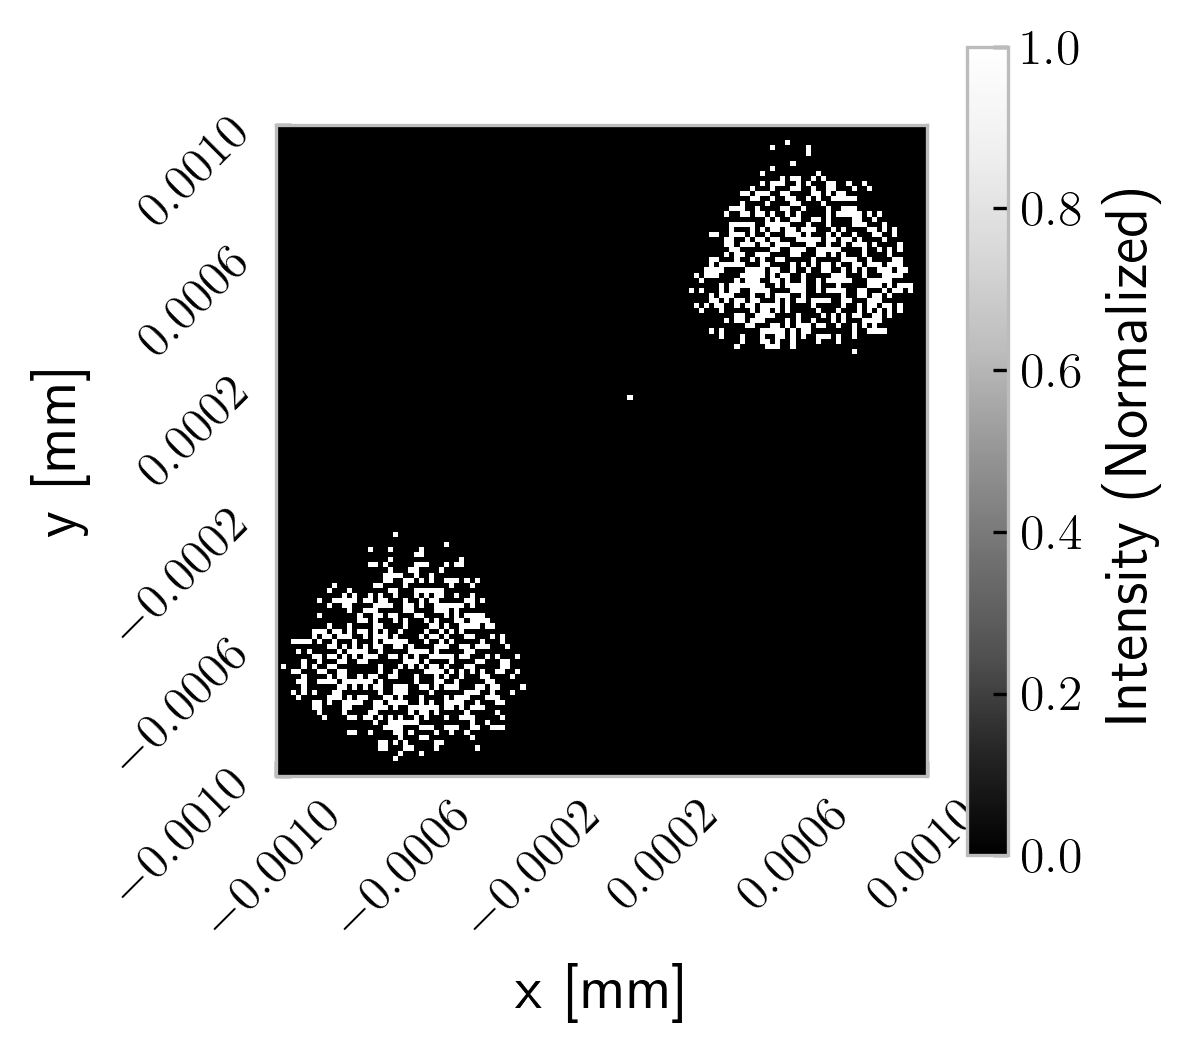

In [228]:
plot_intensity(x, y, result_X)


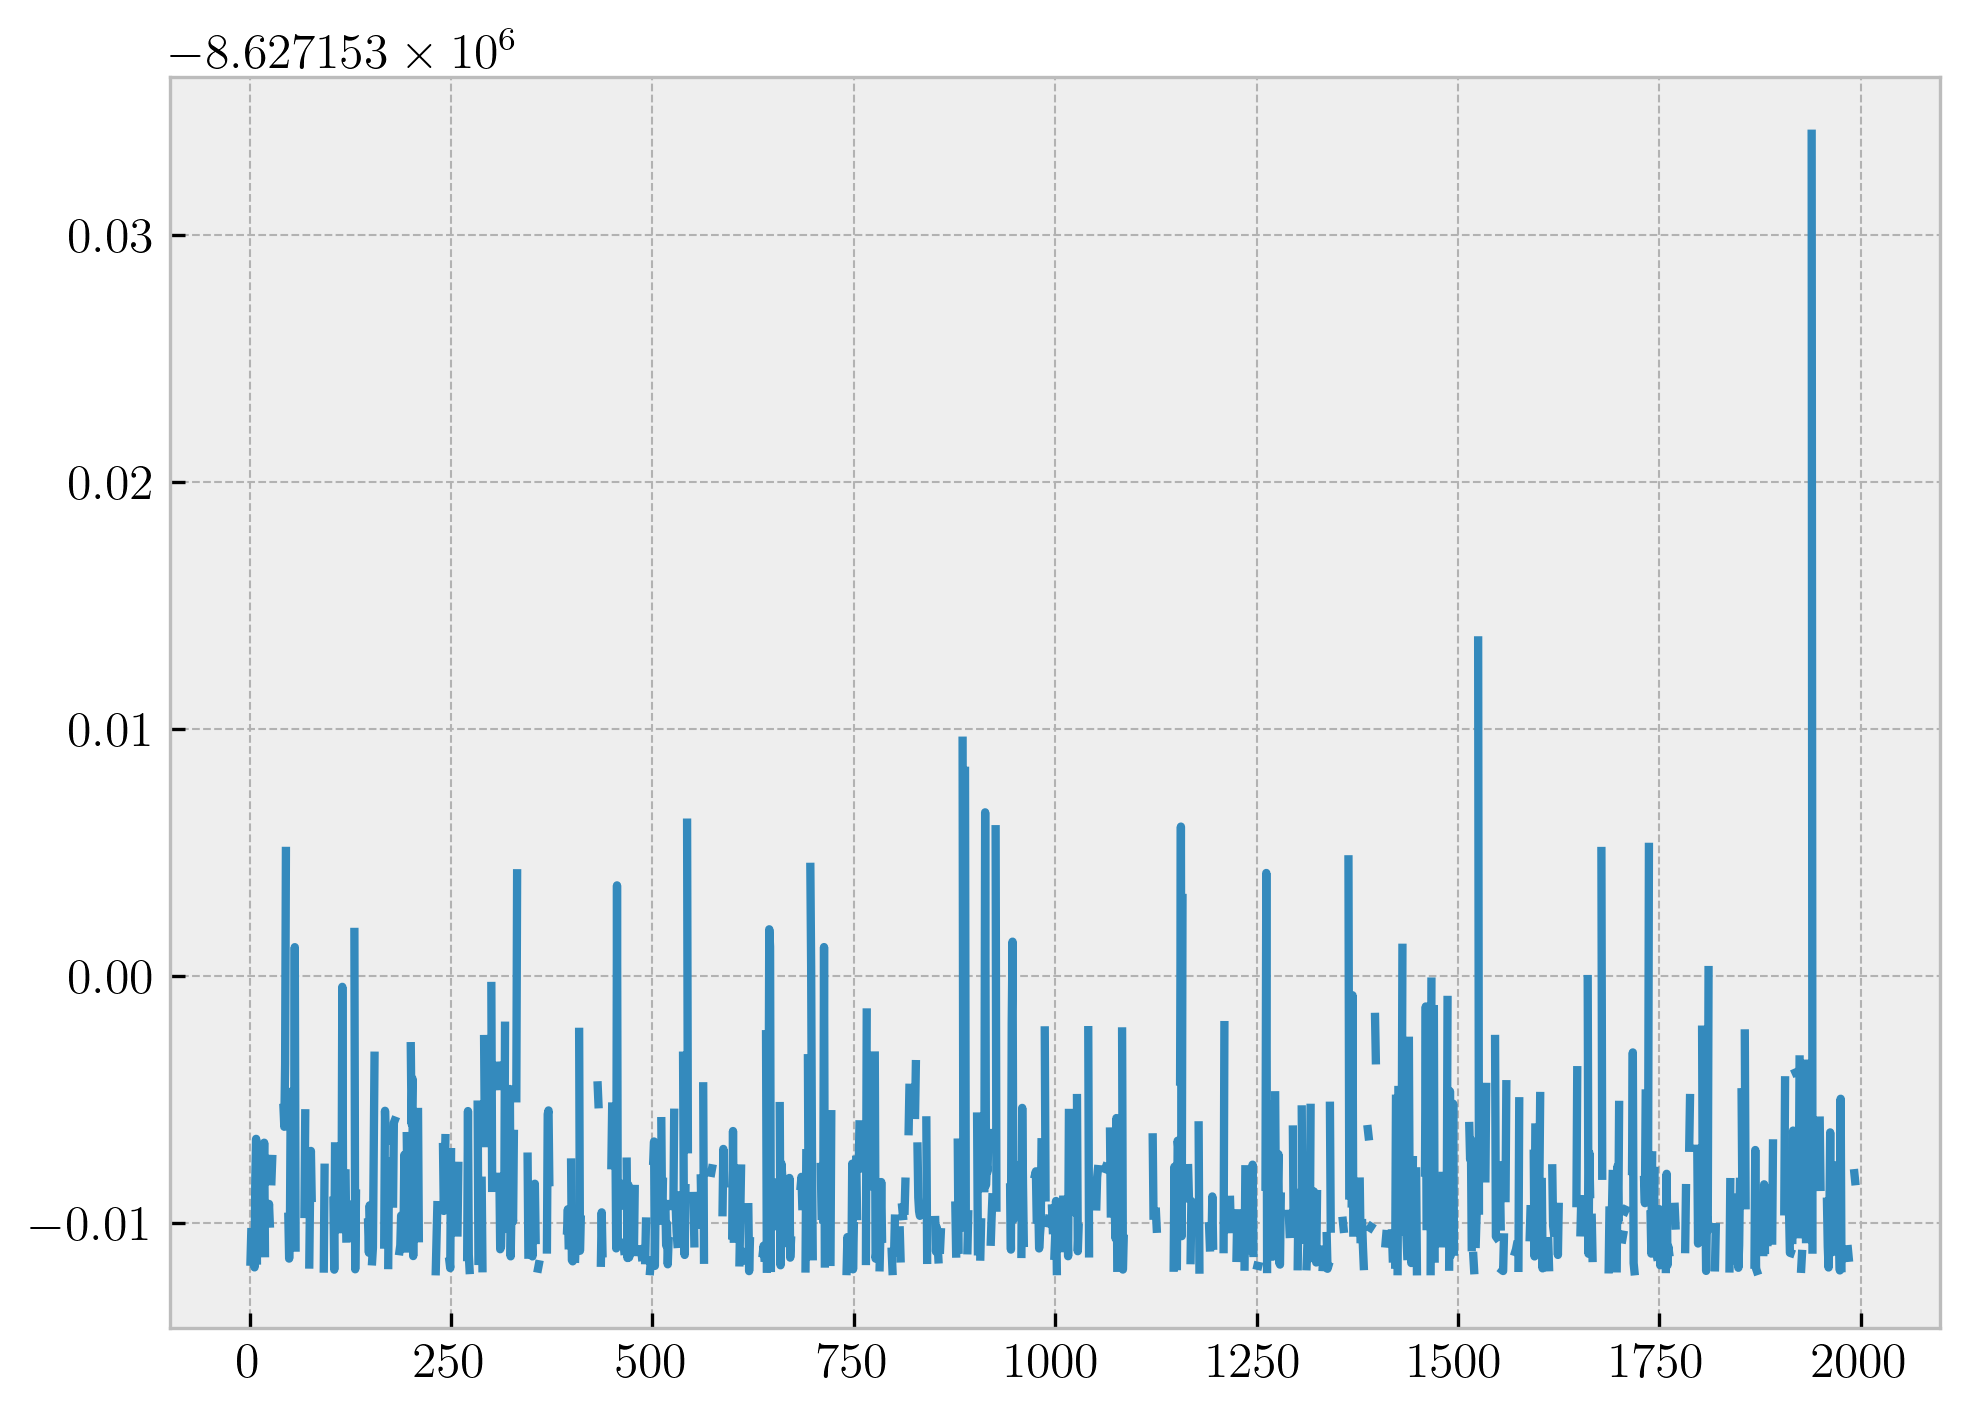

In [229]:
t = np.arange(0, 2000)
plt.plot(t, result_a["log-posterior-trace"])

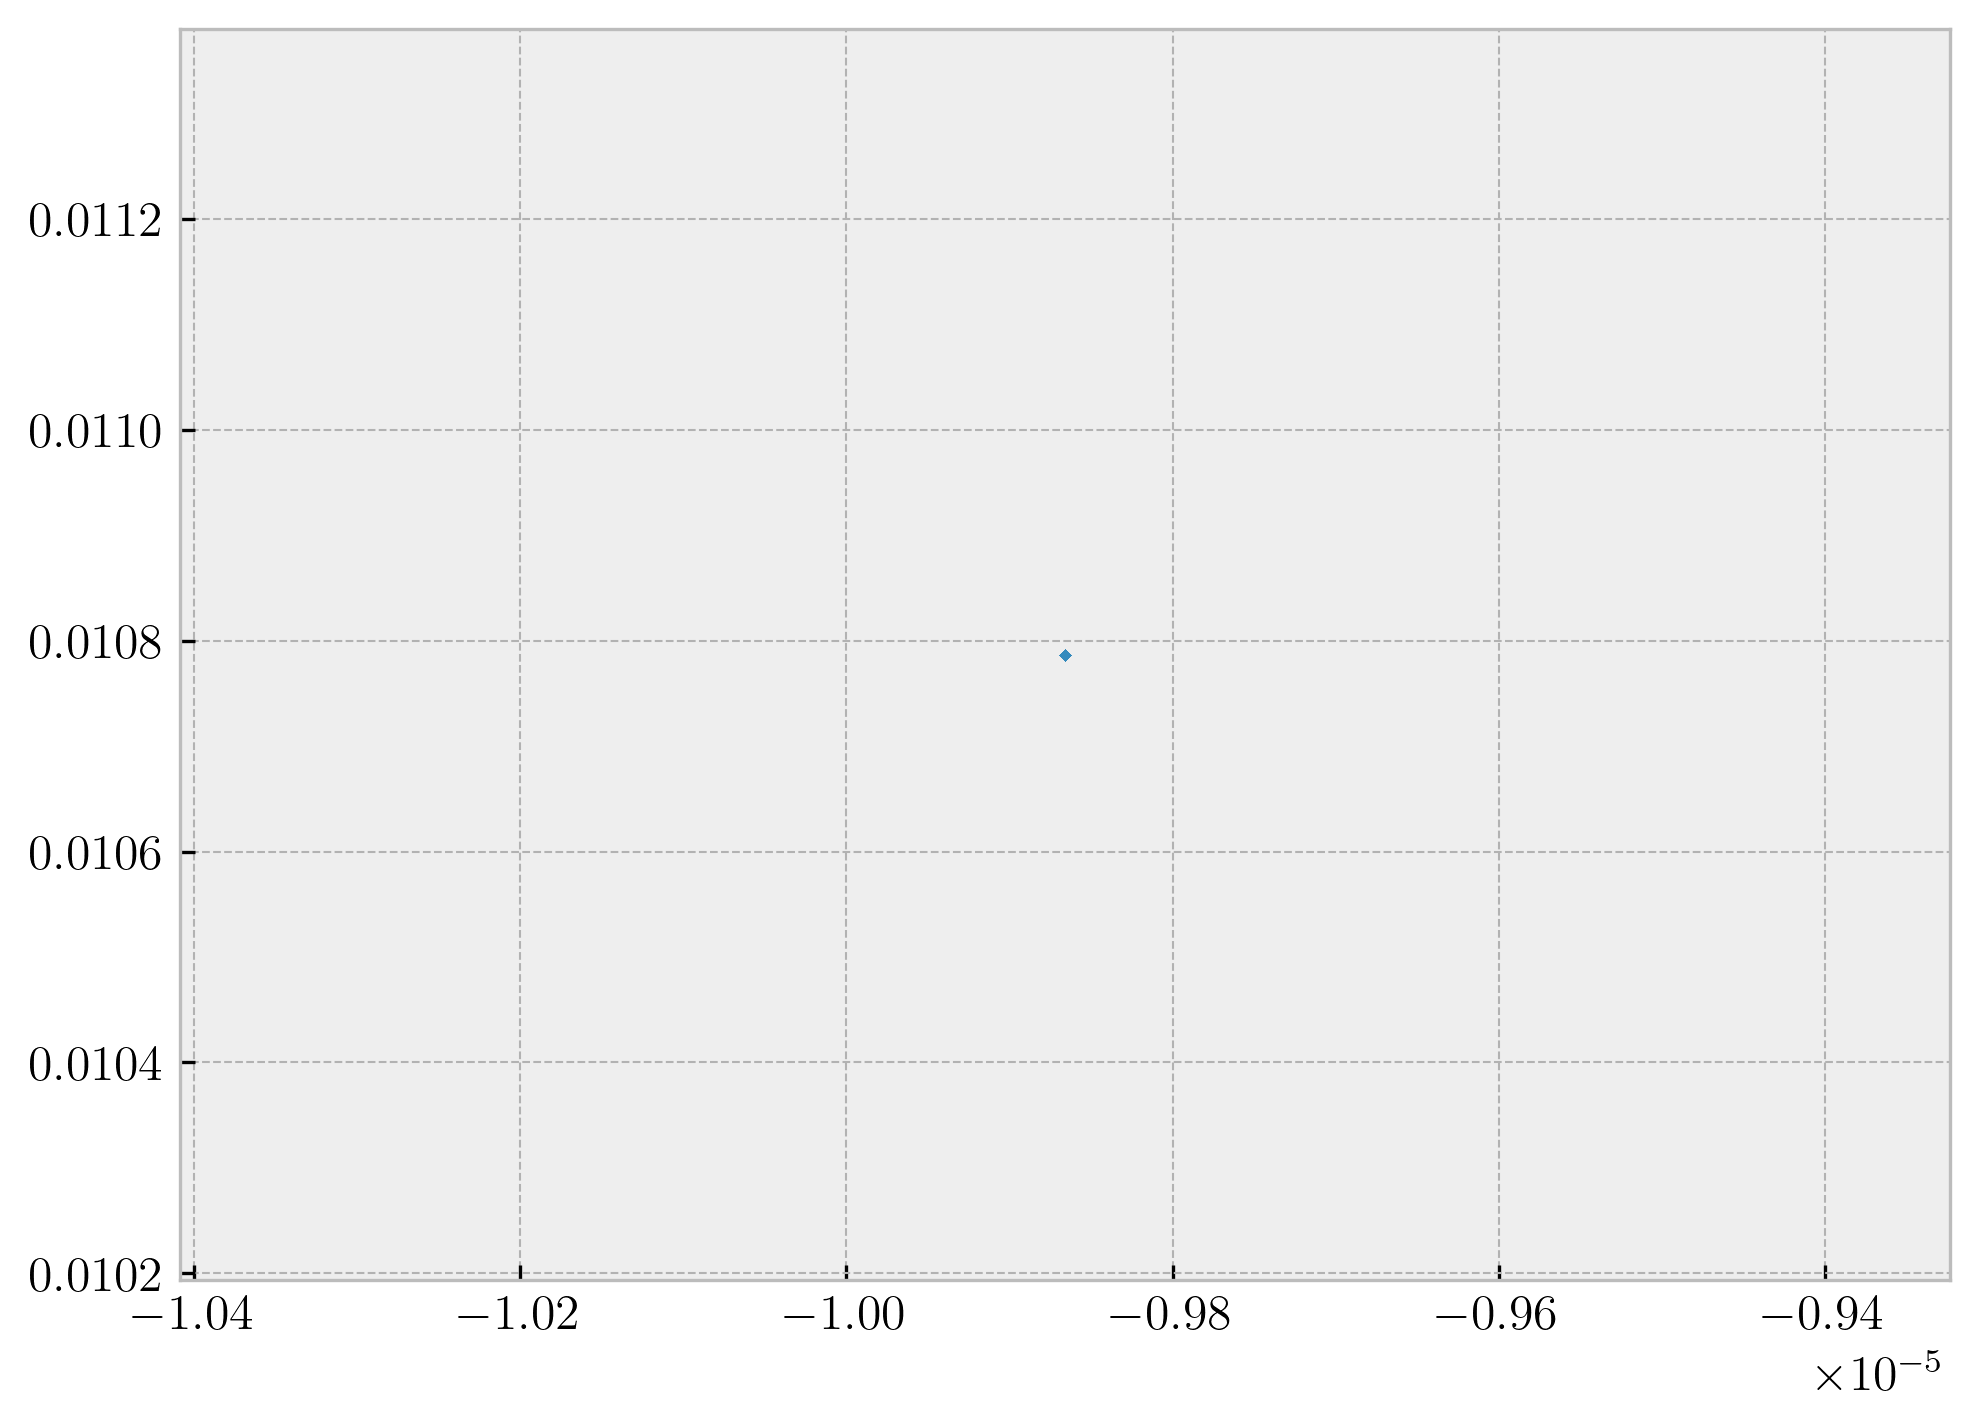

In [230]:
burn_in = 300
multi_data = result_a["a-trace"][-burn_in:]
mode_1 = result_a["a-trace"][:, 0][-burn_in:]
mode_2 = result_a["a-trace"][:, 1][-burn_in:]
fig, ax = plt.subplots(dpi = 300)
ax.scatter(mode_1, mode_2, marker = "x", s = 2)
#ax.scatter(true_c[0], true_c[1], marker = ".", s = 500, c = "red")

/var/folders/v9/czyc2p85057bkq0_b7k6tp2r0000gn/T/ipykernel_43296/1984559295.py:5: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(x=mode_1, y=mode_2, levels=[.05, 0.33], color="black", linewidths=1,


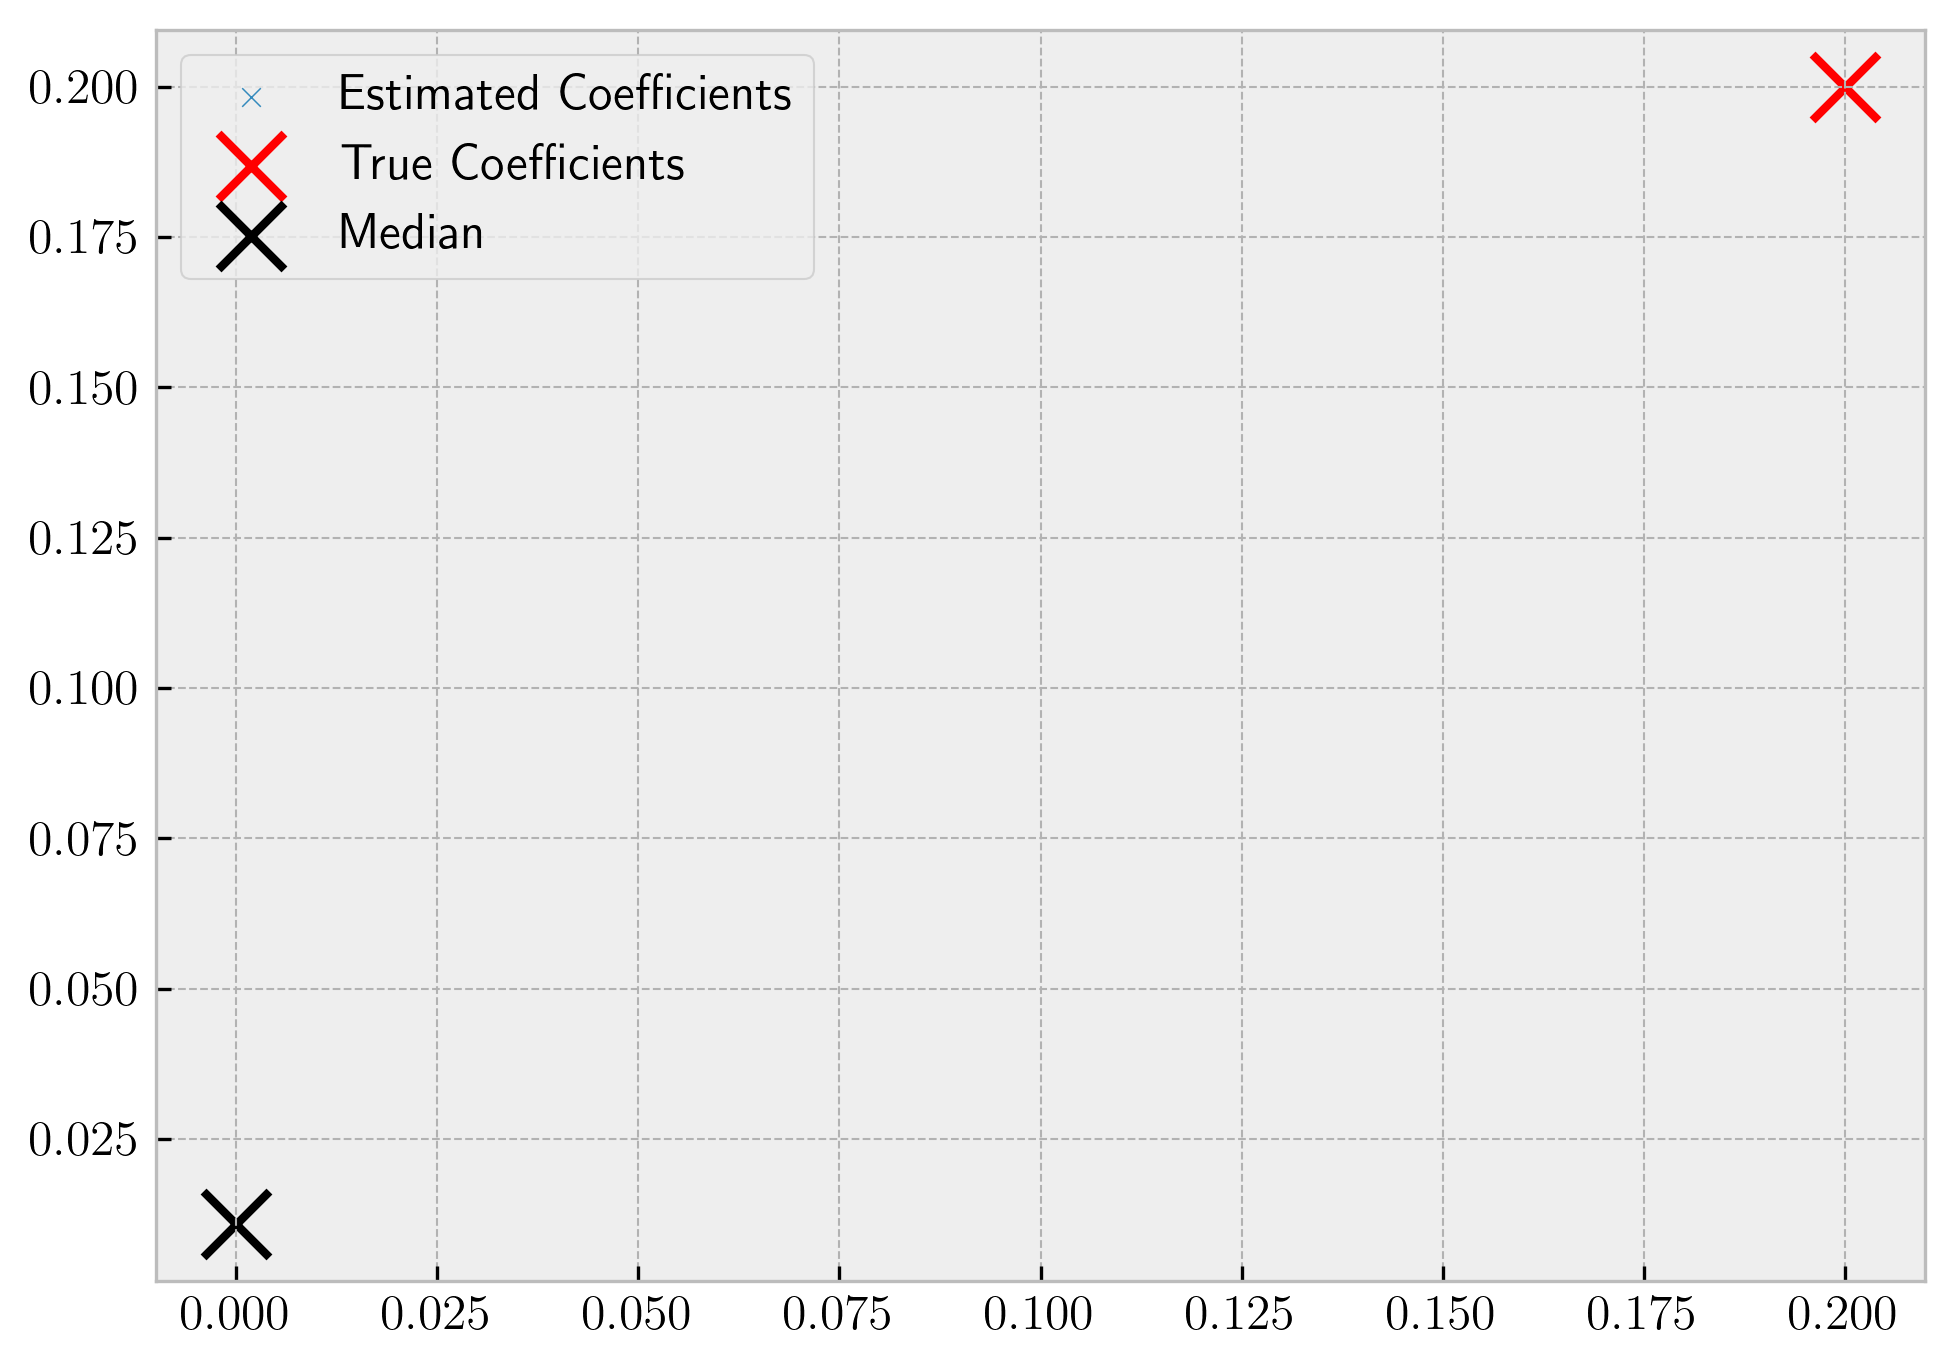

In [231]:
import seaborn as sns
fig, ax = plt.subplots()
sns.scatterplot(x=mode_1, y=mode_2, alpha=1.0, marker = "x", s = 20,
                ax = ax, label = "Estimated Coefficients")
sns.kdeplot(x=mode_1, y=mode_2, levels=[.05, 0.33], color="black", linewidths=1,
            ax = ax, label = "Contours")
ax.scatter(x=true_c[0], y=true_c[1], s = 250, marker = "x", c = "red", label = "True Coefficients")
ax.scatter(x= np.median(mode_1), y = np.median(mode_2), color = "black", label = "Median", marker = "x", s = 250)
ax.set_xlabel("")
ax.legend()


In [156]:
a_estimate = Aberration(true_modes, np.median(multi_data, axis = 0))

x, y, I = microscope.compute_image(Image_Mask(grid, result_X), a_estimate)